In [1]:

# imports
import os
import sys
import types
import json

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = fig_dpi
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  pio.renderers.default = "notebook_connected"
except Exception:
  pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass



# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
if r'/home/tozeng/VT/Courses/CS5805_Machine_Learning/Blogs/posts/regression':
  os.chdir(r'/home/tozeng/VT/Courses/CS5805_Machine_Learning/Blogs/posts/regression')

# reset state
%reset

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v
  
  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define


{"/home/tozeng/mambaforge/envs/quarto/lib/python3.10/importlib/_bootstrap.py": 1698344618.139798, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/importlib/_bootstrap_external.py": 1698344618.139798, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/codecs.py": 1698344617.0197895, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/encodings/aliases.py": 1698344617.6317942, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/encodings/__init__.py": 1698344617.743795, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/encodings/utf_8.py": 1698344617.867796, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/abc.py": 1698344616.979789, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/io.py": 1698344617.10379, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/stat.py": 1698344617.247791, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/_collections_abc.py": 1698344617.0237894, "/home/tozeng/mambaforge/envs/quarto/lib/python3.10/genericpath.py": 1698344617.0717897, "/home/t

/tmp/ipykernel_53940/3522852588.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.pandas
import seaborn as sns

In [3]:
#| label: tbl-head-of-dataset
#| tbl-cap: Samples of the data set
#| tbl-column: page
housing_df = pd.read_csv('data/USA_Housing.csv')
housing_df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
#| tbl-column: body-outset
housing_df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


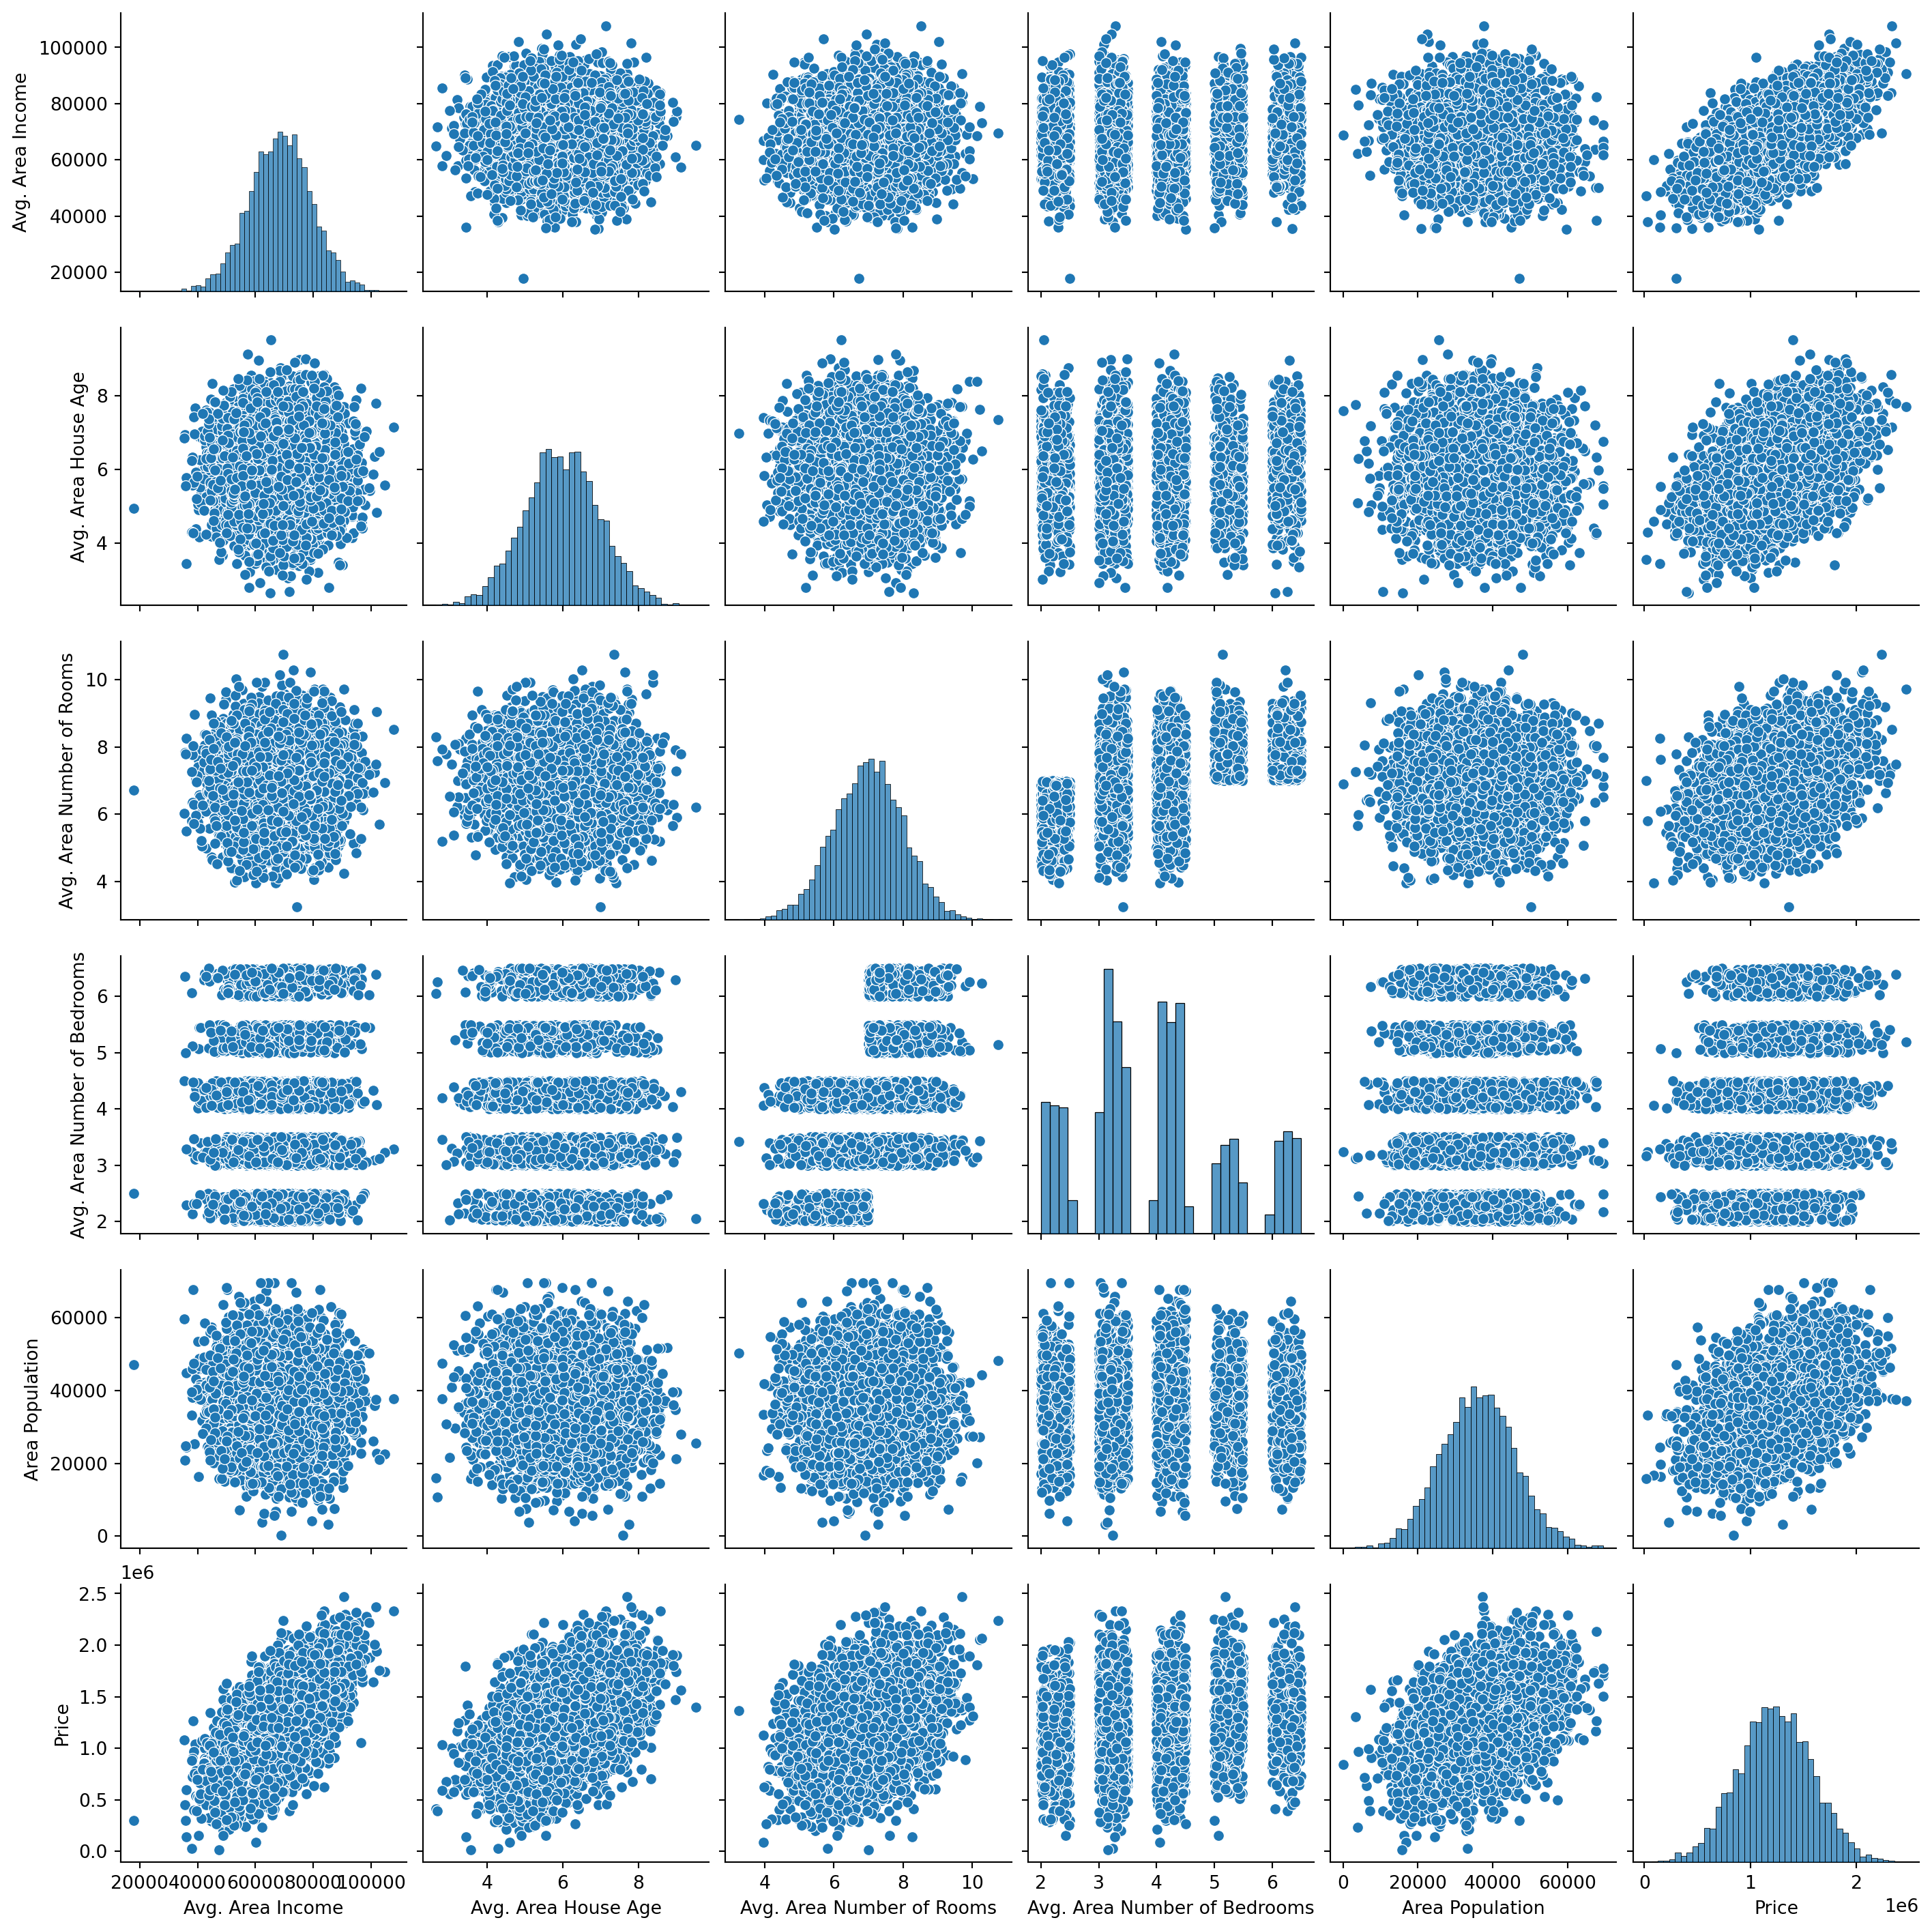

In [5]:
#| label: fig-data-distr
#| fig-cap: The data distribution of variables
#| fig-column: page
sns.pairplot(housing_df)

In [6]:
housing_df.hvplot.hist('Price')

:Histogram   [Price]   (Price_count)

In [7]:
housing_df.hvplot.scatter(x='Avg. Area Income', y='Price')

:Scatter   [Avg. Area Income]   (Price)

In [8]:
housing_df.hvplot.scatter(x='Avg. Area House Age', y='Price')

:Scatter   [Avg. Area House Age]   (Price)

In [9]:
housing_df.hvplot.scatter(x='Avg. Area House Age', y='Price')

:Scatter   [Avg. Area House Age]   (Price)

In [10]:
housing_df.hvplot.scatter(x='Avg. Area Number of Rooms', y='Price')

:Scatter   [Avg. Area Number of Rooms]   (Price)